# LeNet 으로 MNIST 분류하기

In [1]:
import random

import torch
import torch.nn as nn
from torch import optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import numpy as np

import matplotlib.pyplot as plt

In [2]:
is_cuda = torch.cuda.is_available()   # GPU가 사용가능한지
device = torch.device("cuda" if is_cuda else "cpu") # GPU가 사용가능하다면 GPU를 사용 아니면 CPU 사용
print(is_cuda, device)

False cpu


In [ ]:
from torch.utils.data import random_split


def get_mnist_dataloaders(batch_size, val=0.2, num_workers=0):
  transform = transforms.Compose([
    transforms.ToTensor(),
  ])

  # split
  mnist_train_origin = datasets.MNIST(
      root='MNIST/',
      train=True,
      download=True,
      transform=transform,
  )
  val_samples = int(len(mnist_train_origin) * val)
  train_samples = len(mnist_train_origin) - val_samples

  # dataset
  mnist_train, mnist_val = random_split(
      mnist_train_origin,
       (train_samples, val_samples),
  )
  mnist_test = datasets.MNIST(
      root='MNIST/',
      train=False,
      download=True,
      transform=transform,
  )

  # dataloader
  train_loader = DataLoader(
      dataset=mnist_train,
      batch_size=batch_size,
      drop_last=True,
      shuffle=True,
      num_workers=num_workers,
  )
  val_loader = DataLoader(
      dataset=mnist_val,
      batch_size=batch_size,
      num_workers=num_workers,
  )
  test_loader = DataLoader(
      dataset=mnist_test,
      batch_size=batch_size,
      num_workers=num_workers,
  )

  return train_loader, val_loader, test_loader

In [4]:
class LeNet(nn.Module):
  def __init__(self):
    super(LeNet, self).__init__()
    self.conv1 = nn.Conv2d(1, 6, kernel_size=5)
    self.conv2 = nn.Conv2d(6, 16, kernel_size=5)
    self.pool = nn.MaxPool2d(2, 2)
    self.fc1 = nn.Linear(16 * 4 * 4, 120)
    self.fc2 = nn.Linear(120, 84)
    self.fc3 = nn.Linear(84, 10)
    self.relu = nn.ReLU()

  def forward(self, x):
    x  = self.conv1(x)
    x = self.relu(x)
    x = self.pool(x)
    x = self.relu(self.conv2(x))
    x = self.pool(x)
    x = x.view(x.size(0), -1)
    x  = self.fc1(x)
    x = self.relu(x)
    x = self.relu(self.fc2(x))
    x = self.fc3(x)
    return x

In [5]:
def train(model, dataloader, criterion, optimizer, epoch):
  # train mode
  model.train()

  # 학습 통계
  running_loss = 0
  correct = 0

  for i, (data, targets) in enumerate(dataloader):
    data.to(device), targets.to(device)   # data device로 이동

    optimizer.zero_grad()       # gradient 초기화
    outputs = model(data)       # forward
    loss = criterion(outputs, targets)    # loss 계산
    loss.backward()             # gradient 계산
    optimizer.step()            # weight update

    running_loss += loss.item()

    # Accuracy 계산
    _, predicted = torch.max(outputs, 1)
    correct += predicted.eq(targets.view_as(predicted)).sum()

  # Accuracy 출력
  data_num = len(dataloader.dataset)
  acc = 100. * correct / data_num
  print(
      f"[{epoch}/{EPOCH}]",
      f"train loss: {running_loss/len(dataloader):.4f}",
      f"train acc: {correct}/{data_num} ({acc:.2f}%)"
  )

  return running_loss/len(dataloader)

In [6]:
def validation(model, dataloader, criterion, epoch):
  # eval 모드
  model.eval()

  # 검증 통계
  correct = 0
  running_loss = 0.

  with torch.no_grad():   # gradient 계산 안하기
    for i, (data, targets) in enumerate(dataloader):
      data.to(device), targets.to(device)   # data device로 이동

      outputs = model(data)               # forward
      loss = criterion(outputs, targets)  # loss 계산

      running_loss += loss.item()

      # Accuracy 계산
      _, predicted = torch.max(outputs, 1)
      correct += predicted.eq(targets.view_as(predicted)).sum()

  # Accuracy 계산
  data_num = len(dataloader.dataset)
  acc = 100. * correct / data_num
  print(f'[{epoch}/{EPOCH}] valid loss: {running_loss/len(dataloader):.4f} valid acc: {correct}/{data_num} ({acc:.2f}%)\n')

  return running_loss/len(dataloader)

In [7]:
def test(model, dataloader):
  # eval 모드
  model.eval()

  # 테스트 통계
  correct = 0

  with torch.no_grad():
    for data, targets in dataloader:
      data.to(device), targets.to(device)

      outputs = model(data)    # forward

      # Accuracy 계산
      _, predicted = torch.max(outputs, 1)
      correct += predicted.eq(targets.view_as(predicted)).sum()

  # Accuracy 계산
  data_num = len(dataloader.dataset)
  print(f'Test Accuracy: {correct}/{data_num} ({100. * correct / data_num:.2f}%)')

In [9]:
from torch.utils.data import random_split


def get_mnist_dataloaders(batch_size, val=0.2, num_workers=0):
  transform = transforms.Compose([
    transforms.ToTensor(),
  ])

  # split
  mnist_train_origin = datasets.MNIST(
      root='MNIST/',
      train=True,
      download=True,
      transform=transform,
  )
  val_samples = int(len(mnist_train_origin) * val)
  train_samples = len(mnist_train_origin) - val_samples

  # dataset
  mnist_train, mnist_val = random_split(
      mnist_train_origin,
       (train_samples, val_samples),
  )
  mnist_test = datasets.MNIST(
      root='MNIST/',
      train=False,
      download=True,
      transform=transform,
  )

  # dataloader
  train_loader = DataLoader(
      dataset=mnist_train,
      batch_size=batch_size,
      drop_last=True,
      shuffle=True,
      num_workers=num_workers,
  )
  val_loader = DataLoader(
      dataset=mnist_val,
      batch_size=batch_size,
      num_workers=num_workers,
  )
  test_loader = DataLoader(
      dataset=mnist_test,
      batch_size=batch_size,
      num_workers=num_workers,
  )

  return train_loader, val_loader, test_loader

In [11]:
# Hyperparameters
# Training
EPOCH = 5
BATCH_SIZE = 32
NUM_WORKERS = 1
LR = 0.001

# Model
model = LeNet()
print(model)

LeNet(
  (conv1): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1))
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=256, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
  (relu): ReLU()
)


In [12]:
# MNIST dataloader
train_loader, val_loader, test_loader = \
get_mnist_dataloaders(BATCH_SIZE, val=0.2, num_workers=NUM_WORKERS)

100.0%
100.0%
100.0%
100.0%


In [ ]:
# Loss, Optimizer 정의
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

train_losses = []
val_losses = []

for epoch in range(EPOCH):
  tloss = train(model, train_loader, criterion, optimizer, epoch)
  vloss = validation(model, val_loader, criterion, epoch)

  train_losses.append(tloss)
  val_losses.append(vloss)

In [ ]:
test(model, test_loader)

# VGG16로 CIFAR10 데이터셋을 분류하기

In [13]:
import random

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import numpy as np

import matplotlib.pyplot as plt

is_cuda = torch.cuda.is_available()   # GPU가 사용가능한지
device = torch.device("cuda" if is_cuda else "cpu") # GPU가 사용가능하다면 GPU를 사용 아니면 CPU 사용
print(is_cuda, device)

seed = 1010
random.seed(seed)         # python seed
np.random.seed(seed)      # numpy seed
torch.manual_seed(seed)   # torch seed
if device == 'cuda':
  torch.cuda.manual_seed_all(seed)  # gpu seed

False cpu


In [16]:
from torchvision import datasets

trainset = datasets.CIFAR10('CIFAR', train=True, download=True)
testset = datasets.CIFAR10('CIFAR', train=False, download=True)

/home/user/v_pyTorch/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


In [20]:
import pandas as pd
df = pd.DataFrame(trainset.targets)
df_count = df.groupby(0)[0].count()
print(df_count)

df = pd.DataFrame(testset.targets)
df_count = df.groupby(0)[0].count()
print(df_count)

0
0    5000
1    5000
2    5000
3    5000
4    5000
5    5000
6    5000
7    5000
8    5000
9    5000
Name: 0, dtype: int64
0
0    1000
1    1000
2    1000
3    1000
4    1000
5    1000
6    1000
7    1000
8    1000
9    1000
Name: 0, dtype: int64


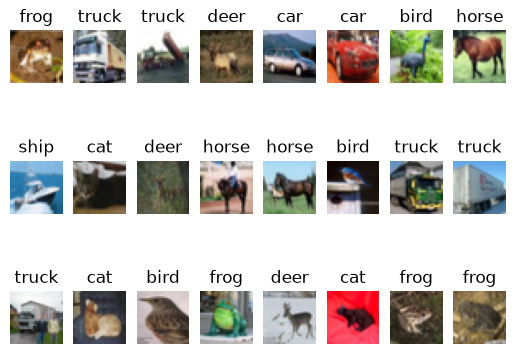

In [21]:
classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

for i in range(24):
  plt.subplot(3,8,i+1)
  img, label = trainset[i]

  plt.gca().set_title(classes[label])
  plt.imshow(img)
  plt.axis('off')
plt.show()

In [22]:
from torch.utils.data import random_split


def get_cifar_datasets(val=0.2, root_dir='CIFAR/'):
  # transform
  transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
  ])

  # split
  train_origin = datasets.CIFAR10(
      root=root_dir,
      train=True,
      download=True,
      transform=transform,
  )
  val_samples = int(len(train_origin) * val)
  train_samples = len(train_origin) - val_samples

  # dataset
  trainset, valset = random_split(
      train_origin,
       (train_samples, val_samples),
  )
  testset = datasets.CIFAR10(
      root=root_dir,
      train=False,
      download=True,
      transform=transform,
  )
  return trainset, valset, testset

dataset_list = get_cifar_datasets()

/home/user/v_pyTorch/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


In [27]:
def train(model, dataloader, criterion, optimizer, epoch, device):
  # train mode
  model.train()

  # 학습 통계
  running_loss = 0
  correct = 0

  for i, (data, targets) in enumerate(dataloader):
    data, targets = data.to(device), targets.to(device)

    optimizer.zero_grad()
    outputs = model(data)
    loss = criterion(outputs, targets)
    loss.backward()
    optimizer.step()

    running_loss += loss.item()

    # Accuracy 계산
    with torch.no_grad():
      _, predicted = torch.max(outputs, 1)
      correct += predicted.eq(targets.view_as(predicted)).sum()

  # Accuracy 출력
  data_num = len(dataloader.dataset)
  acc = 100. * correct / data_num
  print(
      f"[{epoch}/{EPOCH}]",
      f"train loss: {running_loss/len(dataloader):.4f}",
      f"train acc: {correct}/{data_num} ({acc:.2f}%)"
  )

  return running_loss/len(dataloader)

def validation(model, dataloader, criterion, epoch, device):
  # eval 모드
  model.eval()

  # 검증 통계
  correct = 0
  running_loss = 0.

  with torch.no_grad():   # gradient 계산 안하기
    for i, (data, targets) in enumerate(dataloader):
      data, targets = data.to(device), targets.to(device)   # data device로 이동

      outputs = model(data)               # forward
      loss = criterion(outputs, targets)  # loss 계산

      running_loss += loss.item()

      # Accuracy 계산
      _, predicted = torch.max(outputs, 1)
      correct += predicted.eq(targets.view_as(predicted)).sum()

  # Accuracy 계산
  data_num = len(dataloader.dataset)
  acc = 100. * correct / data_num
  print(f'[{epoch}/{EPOCH}] valid loss: {running_loss/len(dataloader):.4f} valid acc: {correct}/{data_num} ({acc:.2f}%)\n')

  return running_loss/len(dataloader)

def test(model, dataloader, device):
  # eval 모드
  model.eval()

  # 테스트 통계
  correct = 0

  with torch.no_grad():
    for data, targets in dataloader:
      data, targets = data.to(device), targets.to(device)

      outputs = model(data)    # forward

      # Accuracy 계산
      _, predicted = torch.max(outputs, 1)
      correct += predicted.eq(targets.view_as(predicted)).sum()

  # Accuracy 계산
  data_num = len(dataloader.dataset)
  print(f'Test Accuracy: {correct}/{data_num} ({100. * correct / data_num:.2f}%)')

In [30]:
!pip install -q torchsummary 

In [37]:
import math
from collections import OrderedDict


class VGG(nn.Module):
  def __init__(self, model, num_classes):
    super().__init__()
    VGG_types = {
        'VGG16' : [64, 64, 'M', 128, 128, 'M', 256, 256, 256, 'M',
                   512, 512, 512, 'M', 512, 512, 512, 'M'],
    }

    self.model = model
    self.feature_extractor = self.create_feature_extractor(VGG_types[model])

    self.fc = nn.Sequential(OrderedDict([
            ('dropout1', nn.Dropout()),
            ('fc1', nn.Linear(512, 512)),
            ('relu1', nn.ReLU(True)),
            ('dropout2', nn.Dropout()),
            ('fc2', nn.Linear(512, 512)),
            ('relu2', nn.ReLU(True)),
            ('fc3', nn.Linear(512, num_classes)),
        ]))

  def create_feature_extractor(self, layers, in_channels=3):
    feature_extractor = []

    for layer in layers:
      if type(layer) == int:
        out_channels = layer

        feature_extractor += [
          nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
          nn.BatchNorm2d(layer),
          nn.ReLU()
        ]
        in_channels = layer
      elif layer == 'M':
        feature_extractor += [nn.MaxPool2d(kernel_size=(2,2), stride=(2,2))]

    return nn.Sequential(*feature_extractor)

  def forward(self, x):
    x = self.feature_extractor(x)
    x = torch.flatten(x, start_dim=1)
    x = self.fc(x)
    return x

In [33]:
vgg = VGG('VGG16', 10)

In [35]:
from torchsummary import summary
summary(VGG('VGG16', 10).to(device), (3, 32, 32))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 32, 32]           1,792
       BatchNorm2d-2           [-1, 64, 32, 32]             128
              ReLU-3           [-1, 64, 32, 32]               0
            Conv2d-4           [-1, 64, 32, 32]          36,928
       BatchNorm2d-5           [-1, 64, 32, 32]             128
              ReLU-6           [-1, 64, 32, 32]               0
         MaxPool2d-7           [-1, 64, 16, 16]               0
            Conv2d-8          [-1, 128, 16, 16]          73,856
       BatchNorm2d-9          [-1, 128, 16, 16]             256
             ReLU-10          [-1, 128, 16, 16]               0
           Conv2d-11          [-1, 128, 16, 16]         147,584
      BatchNorm2d-12          [-1, 128, 16, 16]             256
             ReLU-13          [-1, 128, 16, 16]               0
        MaxPool2d-14            [-1, 12

In [38]:
# Hyperparameters
# Training

# Model
model = VGG('VGG16', num_classes=10).to(device)

# CIFAR dataloader
trainset, valset, testset = get_cifar_datasets(val=0.2)

# dataloader
train_loader = DataLoader(
    dataset=trainset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
)
val_loader = DataLoader(
    dataset=valset,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
)
test_loader = DataLoader(
    dataset=testset,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
)

In [40]:
# Hyperparameters
EPOCH = 50
BATCH_SIZE = 32
NUM_WORKERS = 1
LR = 0.0001 # 1e-4

# Loss, Optimizer 정의
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

train_losses = []
val_losses = []

for epoch in range(1, EPOCH+1):
  tloss = train(model, train_loader, criterion, optimizer, epoch, device)
  vloss = validation(model, val_loader, criterion, epoch, device)

  train_losses.append(tloss)
  val_losses.append(vloss)

[1/50] train loss: 1.5186 train acc: 16903/40000 (42.26%)
[1/50] valid loss: 1.1065 valid acc: 6022/10000 (60.22%)



KeyboardInterrupt: 

In [ ]:
# torch.save(model, 'vgg_cifar10.pth')

In [ ]:
model = torch.load('vgg_cifar10.pth')

In [ ]:
https://drive.google.com/file/d/1QfxuA4x11NgV5uqOGWeQr2ouwvfQvKy8/view?usp=sharing

In [43]:
# !pip install gdown
import gdown

In [45]:
gdown.download(id="1QfxuA4x11NgV5uqOGWeQr2ouwvfQvKy8", output="vgg16_cifar10.pth", quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=1QfxuA4x11NgV5uqOGWeQr2ouwvfQvKy8
From (redirected): https://drive.google.com/uc?id=1QfxuA4x11NgV5uqOGWeQr2ouwvfQvKy8&confirm=t&uuid=731bac21-a406-4f46-849b-b99939325110
To: /home/user/DL/lesson/pyTorch/vgg16_cifar10.pth
100%|████████████████████████████████████████| 61.1M/61.1M [00:01<00:00, 35.9MB/s]


'vgg16_cifar10.pth'

In [49]:
model = torch.load("vgg16_cifar10.pth", weights_only=False, map_location=torch.device('cpu'))

- 1. VGG16 모델로 cifar10의 testset을 넣어서 정확도를 구해 주세요. model.eval()
- 2. VGG16 모델로 MNIST 데이터셋으로 훈련, 검증, 테스트 를 해 주세요.
- 3. LeNet 모델로 cats_and_dogs.zip 으로 이진분류를 해 봅시다.